In [9]:
import numpy as np
import matplotlib.pyplot as plt

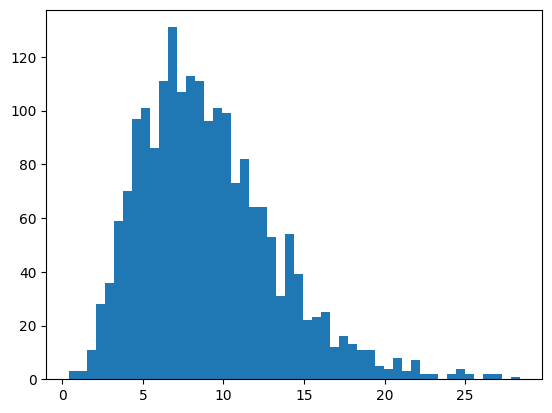

In [15]:
rng = np.random.default_rng(seed=123)
m = 2000

boylar = rng.normal(loc=175, scale=10, size=(m,1))
yashlar = rng.uniform(low=18, high=65, size=(m,1))

maashlar = rng.gamma(shape=4.5, scale=2, size=(m,1))

plt.hist(maashlar, bins=50)
plt.show()

In [31]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([boylar/100, yashlar/100])
y = maashlar.copy() / 10

X_b = add_dummy_feature(X)
X_b

array([[1.        , 1.65108786, 0.54917037],
       [1.        , 1.71322133, 0.57575708],
       [1.        , 1.87879253, 0.43439939],
       ...,
       [1.        , 1.61721291, 0.64432248],
       [1.        , 1.87379982, 0.53938548],
       [1.        , 1.87188795, 0.37919932]], shape=(2000, 3))

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} X^T(X\mathbf{\theta} - \mathbf{y})$$

$$\mathbf{\theta}_{new} := \mathbf{\theta}_{old} - \eta \ \nabla J(\mathbf{\theta}_{old})$$

In [ ]:
eta = 0.2
m = len(X_b)

n_epochs = 100000

# theta = rng.normal(loc=0, scale=1, size=(3,1))
theta = rng.standard_normal(size=(3,1))

for epoch in range(n_epochs):
	gradient = 1/m * X_b.T @ (X_b @ theta - y)
	theta = theta - eta * gradient

theta

array([[ 1.16241095],
       [-0.1423537 ],
       [-0.01390461]])

In [44]:
X_test = np.array([
	[1., 1.73, 0.29]
])
X_test @ theta

array([[0.90901194]])

In [50]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)
lr.coef_, lr.intercept_

(array([[-0.1423537 , -0.01390461]]), array([1.16241095]))